# Consigna

# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [537]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''
        noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Genera ruido gaussiano con varianza var.

        Nota: El ruido blanco se define como normal o gaussiano, con media 0 y con una varianza igual a la potencia de ruido
        (Extraido de apuntes de ASYS de procesos estocásticos, "ruido blanco")
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=var, size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    var_noise = ((vmax**2)/2) / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    return np.mean(x**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))


# Respuesta

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [538]:
def mi_adc(xx, Vfs, B):
    '''
    Cuantizador que simula el comportamiento de un ADC
    xx: Señal a convertir
    Vfs: ADC [0, Vfs]
    B: cantidad de Bits.
    fs: Frecuencia de muestreo.
    ''' 
    q = Vfs/(2**B) 
    xd = np.round(xx/q) * q
    #xd[xd > q*(2**(B-1)-1)] = q*(2**(B-1)-1)
    #xd[xd < -q*2**(B-1)] = -q*2**(B-1) 
    return xd

def autocorrelate(xx):
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size
    return autocorr[autocorr.size//2:]
    

In [539]:
##### Variables
vmax = 2**.5    # Vpico
freq = 100      # Freq
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq

VFS = 4
Bits = 8

##### Funcion
xx, t = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)
xd = mi_adc(xx, VFS, Bits)


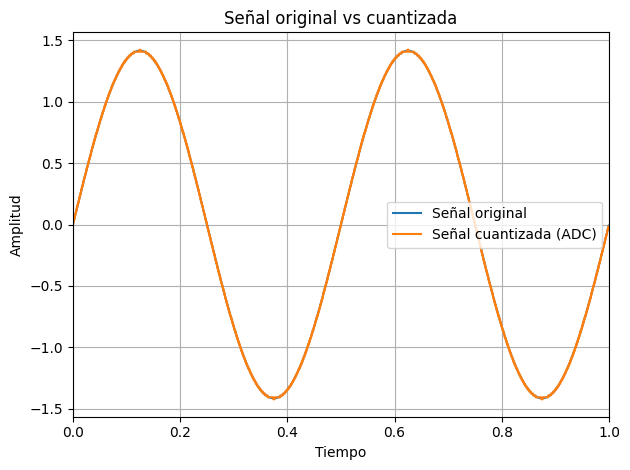

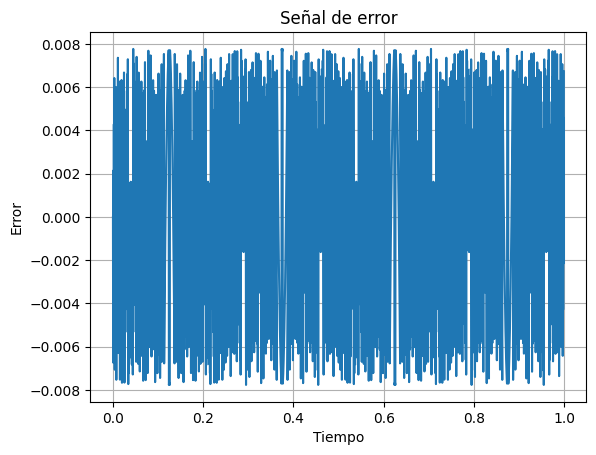

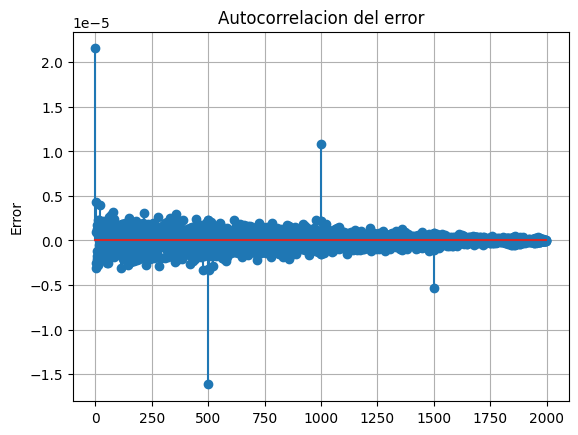

varianza: 2.1555486531986383e-05
Potencia de autocorrelacion: 2.1555486531986383e-05
Cálculo matemático: 2.0345052083333332e-05


In [540]:
x_max = 2/freq

plt.figure()
plt.plot(t, xx, label="Señal original")
plt.step(t, xd, where='mid', label="Señal cuantizada (ADC)")
plt.xlim([0, x_max])
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Señal original vs cuantizada")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Señal de Error #####
error = xx - xd
plt.figure()
plt.plot(t, error)
plt.xlabel("Tiempo")
plt.ylabel("Error")
plt.title("Señal de error")
plt.grid()

plt.show()

# Señal de Error #####
autocorr_error = autocorrelate(error)
#error_fft = np.fft.fft(error, axis=0)
plt.figure()
plt.stem(autocorr_error)
plt.ylabel("Error")
plt.title("Autocorrelacion del error")
plt.grid()

plt.show()
print(f"varianza: {np.var(error, axis=0)[0]}")
print(f"Potencia de autocorrelacion: {autocorr_error[0]}")
q = VFS/2**Bits
print(f"Cálculo matemático: {q**2/12}")


## Caso 2: 

Senoidal con ruido

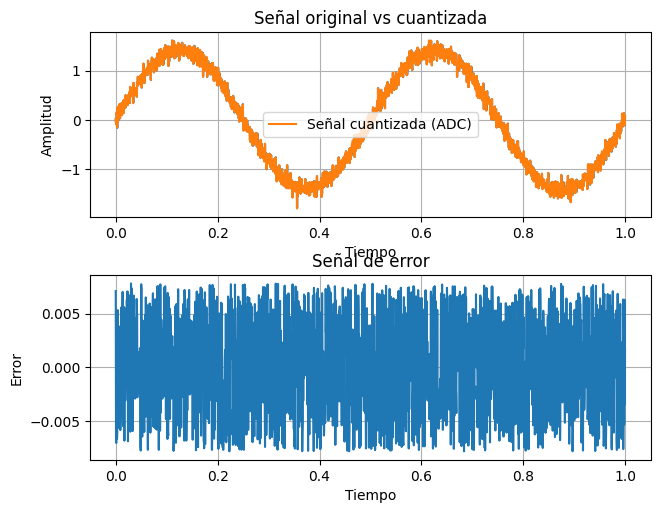

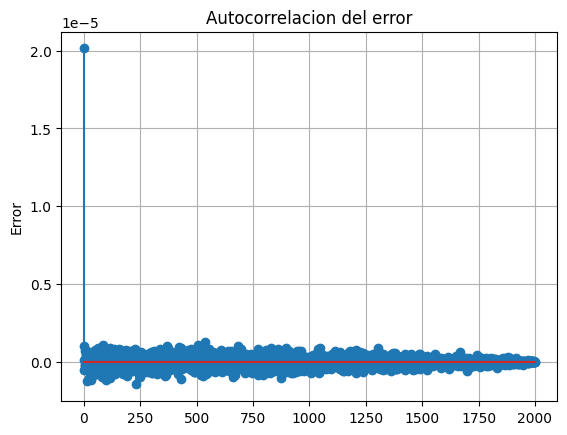

varianza: 2.0128318019143962e-05
Potencia de autocorrelacion: 2.0140038243221588e-05
Cálculo matemático (q^2/12): 2.0345052083333332e-05


In [541]:
##### Variables
vmax = 2**.5    # Vpico
freq = 100      # Freq
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq

##### Funcion
VFS = 4 
Bits = 8
xx, t = mi_sen_ruidosa(vmax, ff=freq, ph=ph, nn=N, fs=fs, snr=10)
xq = mi_adc(xx, VFS, Bits)

plt.figure()
plt.subplot(2,1,1)
plt.plot(t, xx)
plt.step(t, xq, label="Señal cuantizada (ADC)")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Señal original vs cuantizada")
plt.legend()
plt.grid()
plt.tight_layout()


# Señal de Error #####
error = xx - xq
plt.subplot(2,1,2)
plt.plot(t, error)
plt.xlabel("Tiempo")
plt.ylabel("Error")
plt.title("Señal de error")
plt.grid()

plt.show()

# Señal de Error #####
autocorr_error = autocorrelate(error)
plt.figure()
plt.stem((autocorr_error))
plt.ylabel("Error")
plt.title("Autocorrelacion del error")
plt.grid()

plt.show()
print(f"varianza: {np.var(error, axis=0)[0]}")
print(f"Potencia de autocorrelacion: {autocorr_error[0]}")
q = VFS/2**Bits
print(f"Cálculo matemático (q^2/12): {q**2/12}")


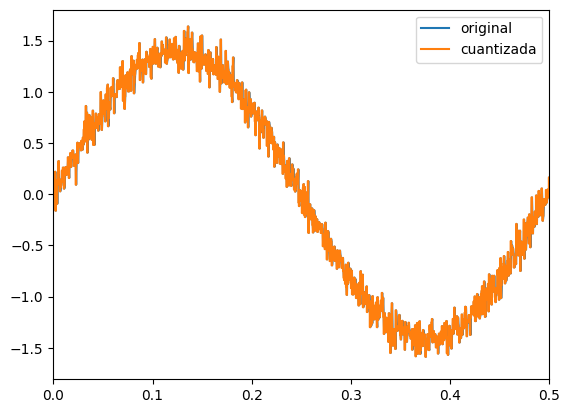

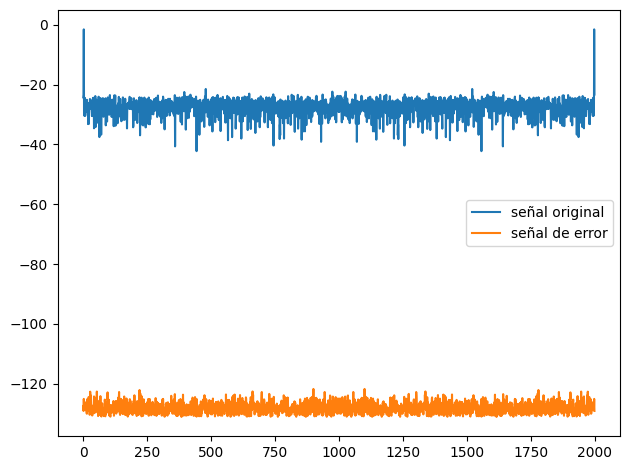

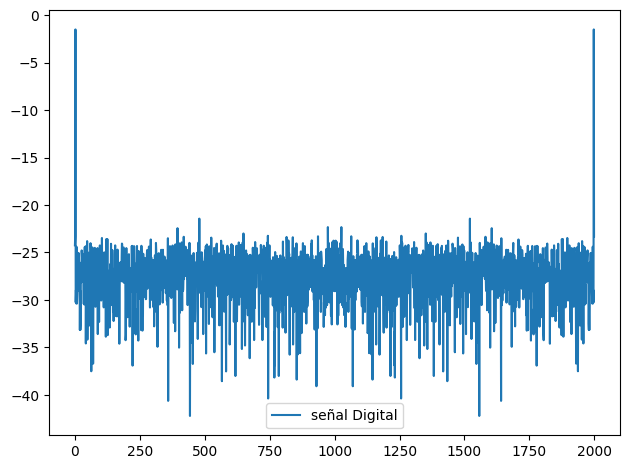

In [542]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq

# ADC
VFS = 4 
Bits = 16

##### Funcion
xx, t = mi_sen_ruidosa(vmax, ff=freq, ph=ph, nn=N, fs=fs, snr=10)
xq = mi_adc(xx, VFS, Bits)
error = xx - xq
autocorr_error = autocorrelate(error)
plt.figure()
plt.plot(t,xx, label='original')
plt.step(t,xq, label='cuantizada')
plt.xlim([0, 1/freq])
plt.legend()
plt.show()


### Cálculo de fft
x_fft = np.fft.fft(xx, axis=0)/N
autocorr_err_fft = np.fft.fft(autocorr_error)/N
plt.figure()
plt.plot(10*np.log10(np.abs(x_fft)), label='señal original')
plt.plot(10*np.log10(np.abs(autocorr_err_fft)), label='señal de error')
plt.legend()
plt.tight_layout()
plt.show()

xq_fft = np.fft.fft(xq, axis=0)/N
plt.figure()
plt.plot(10*np.log10(np.abs(xq_fft)), label='señal Digital')
plt.legend()
plt.tight_layout()
plt.show()


# Correlacion entre señales

Prueba de correlaciones

Potencia: 0.008729442800587076


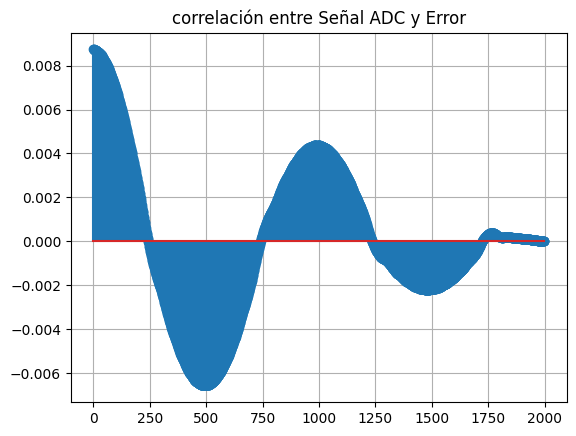

In [543]:
##### Variables
vmax = 2**.5    # Vpico
freq = 100      # Freq
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq
VFS = 4 
Bits = 4

##### Funciones
xx, t = mi_funcion_sen(vmax, ff=freq, ph=ph, nn=N, fs=fs)
xd = mi_adc(xx, VFS, Bits)
error = xd - xx

##### Correlaciones
corr_xd_error = np.correlate(xx.flatten(), error.flatten(), mode='full')/xx.size
corr_xd_error = corr_xd_error[corr_xd_error.size//2:]



#### Plots
plt.figure()
plt.stem(corr_xd_error)
plt.title('correlación entre Señal ADC y Error')
print(f"Potencia: {corr_xd_error[0]}")
plt.grid()
plt.show()